
========== RESULTADO ==========
Melhor rota encontrada:
[0, 1, 2, 4, 5]

Melhor custo:
8.0


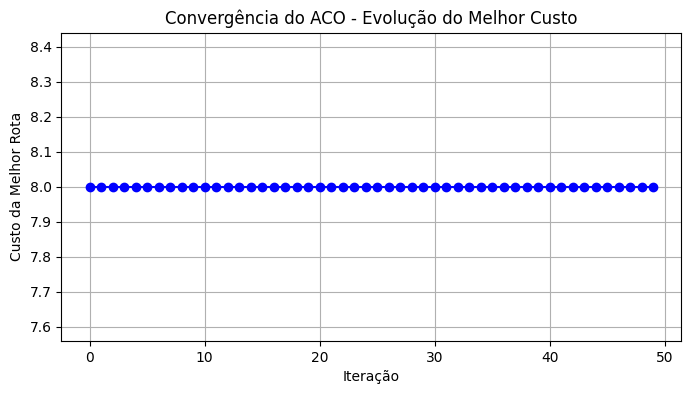

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# 1 - Representar a rede utilizando uma matriz de custos
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# Parâmetros mínimos
NUM_FORMIGAS = 20
NUM_ITERACOES = 50
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.5
Q = 100

# 2 - Criar uma matriz de feromônio
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

def obter_vizinhos(no):
    #Retorna os vizinhos acessíveis de um nó.
    return [i for i in range(len(CUSTOS)) if i != no and CUSTOS[no][i] != np.inf]

def calcular_atratividade(atual, proximo):
    #Calcula o quão atraente é o próximo nó.
    return (feromonio[atual][proximo] ** ALPHA) * ((1 / CUSTOS[atual][proximo]) ** BETA)

# 4 - Fazer cada formiga construir uma rota
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        vizinhos = obter_vizinhos(atual)

        # 5 - Impedir que uma formiga visite novamente um nó (evita loops)
        candidatos = [n for n in vizinhos if n not in rota]

        if not candidatos:
            return None # Formiga ficou presa, rota inválida

        atratividades = [calcular_atratividade(atual, c) for c in candidatos]
        soma = sum(atratividades)
        probabilidades = [a / soma for a in atratividades]

        # Escolha probabilística baseada na atratividade
        proximo = random.choices(candidatos, weights=probabilidades, k=1)[0]
        rota.append(proximo)
        atual = proximo

    return rota

# 6 - Calcular o custo de cada rota
def calcular_custo(rota):
    return sum(CUSTOS[rota[i]][rota[i+1]] for i in range(len(rota) - 1))

# 8 - Aplicar evaporação
def evaporar_feromonio():
    global feromonio
    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

# 7 - Reforçar as melhores rotas com feromônio
def depositar_feromonio(rota, custo):
    deposito = Q / custo
    for i in range(len(rota) - 1):
        feromonio[rota[i]][rota[i+1]] += deposito


# main

melhor_rota = None
melhor_custo = float('inf')
historico = []

# 9 - Repetir o processo por várias iterações
for _ in range(NUM_ITERACOES):
    rotas_da_iteracao = []

    # 3 - Criar várias formigas
    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()
        if rota is not None:
            custo = calcular_custo(rota)
            rotas_da_iteracao.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas_da_iteracao:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)
print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:")
print(melhor_rota)
print(f"\nMelhor custo:\n{melhor_custo}")
plt.figure(figsize=(8, 4))
plt.plot(historico, marker='o', linestyle='-', color='b')
plt.title("Convergência do ACO - Evolução do Melhor Custo")
plt.xlabel("Iteração")
plt.ylabel("Custo da Melhor Rota")
plt.grid(True)
plt.show()


========== RESULTADO ==========
Melhor rota encontrada:
[0, 1, 2, 3, 4, 5]

Melhor custo:
8.0


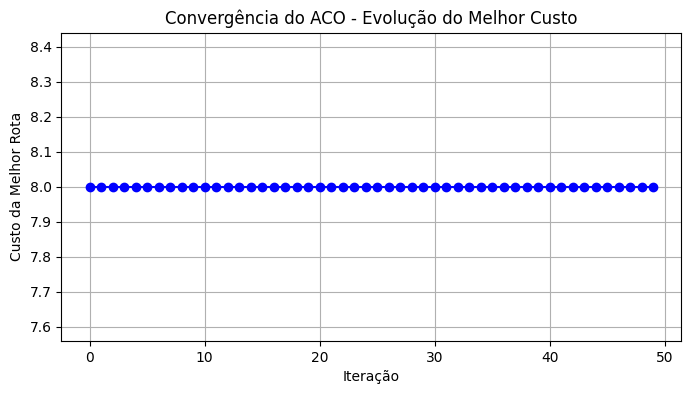

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

# 1 - Representar a rede utilizando uma matriz de custos
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# Parâmetros mínimos
NUM_FORMIGAS = 50
NUM_ITERACOES = 50
ALPHA = 0.1
BETA = 0.1
TAXA_EVAPORACAO = 0.9
Q = 100

# 2 - Criar uma matriz de feromônio
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

def obter_vizinhos(no):
    #Retorna os vizinhos acessíveis de um nó.
    return [i for i in range(len(CUSTOS)) if i != no and CUSTOS[no][i] != np.inf]

def calcular_atratividade(atual, proximo):
    #Calcula o quão atraente é o próximo nó.
    return (feromonio[atual][proximo] ** ALPHA) * ((1 / CUSTOS[atual][proximo]) ** BETA)

# 4 - Fazer cada formiga construir uma rota
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        vizinhos = obter_vizinhos(atual)

        # 5 - Impedir que uma formiga visite novamente um nó (evita loops)
        candidatos = [n for n in vizinhos if n not in rota]

        if not candidatos:
            return None # Formiga ficou presa, rota inválida

        atratividades = [calcular_atratividade(atual, c) for c in candidatos]
        soma = sum(atratividades)
        probabilidades = [a / soma for a in atratividades]

        # Escolha probabilística baseada na atratividade
        proximo = random.choices(candidatos, weights=probabilidades, k=1)[0]
        rota.append(proximo)
        atual = proximo

    return rota

# 6 - Calcular o custo de cada rota
def calcular_custo(rota):
    return sum(CUSTOS[rota[i]][rota[i+1]] for i in range(len(rota) - 1))

# 8 - Aplicar evaporação
def evaporar_feromonio():
    global feromonio
    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

# 7 - Reforçar as melhores rotas com feromônio
def depositar_feromonio(rota, custo):
    deposito = Q / custo
    for i in range(len(rota) - 1):
        feromonio[rota[i]][rota[i+1]] += deposito


# main

melhor_rota = None
melhor_custo = float('inf')
historico = []

# 9 - Repetir o processo por várias iterações
for _ in range(NUM_ITERACOES):
    rotas_da_iteracao = []

    # 3 - Criar várias formigas
    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()
        if rota is not None:
            custo = calcular_custo(rota)
            rotas_da_iteracao.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas_da_iteracao:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)
print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:")
print(melhor_rota)
print(f"\nMelhor custo:\n{melhor_custo}")
plt.figure(figsize=(8, 4))
plt.plot(historico, marker='o', linestyle='-', color='b')
plt.title("Convergência do ACO - Evolução do Melhor Custo")
plt.xlabel("Iteração")
plt.ylabel("Custo da Melhor Rota")
plt.grid(True)
plt.show()